In [268]:
import pandas as pd
import json
import numpy as np
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parents[3]

df=pd.read_csv(project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/Full_set.csv')
df.drop(columns=['Unnamed: 0'],inplace=True)

In [269]:
tab = (
    data_HY.groupby(["EVENT_ID", "STAGE"])
      .size()
      .unstack("STAGE", fill_value=0)
      .reindex(columns=[0,1,2], fill_value=0)
)

# 5) Total por fila
tab["Total"] = tab.sum(axis=1)

tab

STAGE,0,1,2,Total
EVENT_ID,,,,
1,462,477,17,956
2,442,480,34,956
3,442,466,48,956
4,408,476,72,956


# Pipeline completo LSTM PyTorch

In [270]:
# =========================================================
# PIPELINE COMPLETO EN PYTORCH PARA LSTM MULTICLASE T4
# Usa t1, t2, t3 para predecir la clase de t4
# =========================================================

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Utilidades generales

In [271]:
# =========================
# UTILIDADES
# =========================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def make_loader(X, y, batch_size=16, shuffle=False):
    """
    X shape: (n_samples, 3, n_features)
    y shape: (n_samples,)
    """
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)

    ds = TensorDataset(X_t, y_t)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle
    )

## Crear X e y sin fuga de información de t4

In [272]:
# =========================
# CREACIÓN DE SECUENCIAS
# =========================

def crear_X_y_lstm_t4(
    df,
    id_col,
    time_col,
    target_col,
    feature_cols=None,
    input_steps=3,
):
    """
    Convierte un dataframe largo en formato LSTM.

    Para cada serie:
        X = features de t1, t2, t3
        y = clase de t4

    No usa ningún feature de t4 en X.

    Devuelve:
        X shape: (n_series, 3, n_features)
        y shape: (n_series,)
        serie_ids: ids usados
    """

    df = df.copy()

    assert id_col in df.columns, f"No existe id_col: {id_col}"
    assert time_col in df.columns, f"No existe time_col: {time_col}"
    assert target_col in df.columns, f"No existe target_col: {target_col}"

    if feature_cols is None:
        feature_cols = [
            c for c in df.columns
            if c not in [id_col, time_col, target_col]
        ]

    if target_col in feature_cols:
        raise ValueError(
            f"{target_col} no puede estar en feature_cols porque causa fuga de información."
        )

    X_list = []
    y_list = []
    ids_list = []

    for serie_id, grupo in df.groupby(id_col):
        grupo = grupo.sort_values(time_col).reset_index(drop=True)

        # Necesitamos t1, t2, t3 para X y t4 para y
        if len(grupo) < input_steps + 1:
            continue

        # X: SOLO t1, t2, t3
        X_i = grupo.iloc[:input_steps][feature_cols].astype(np.float32).values

        # y: SOLO clase de t4
        y_i = grupo.iloc[input_steps][target_col]

        X_list.append(X_i)
        y_list.append(y_i)
        ids_list.append(serie_id)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list)

    return X, y, ids_list, feature_cols

## Escalado para datos 3D

In [273]:
# =========================
# ESCALADO 3D
# =========================

def fit_transform_lstm_scaler(X_train, X_val=None, X_test=None):
    """
    Escala X con shape:
        (n_samples, timesteps, n_features)

    Ajusta el scaler solo con X_train.
    """

    scaler = StandardScaler()

    n_train, timesteps, n_features = X_train.shape

    X_train_2d = X_train.reshape(-1, n_features)
    X_train_scaled = scaler.fit_transform(X_train_2d)
    X_train_scaled = X_train_scaled.reshape(n_train, timesteps, n_features)

    outputs = [X_train_scaled]

    if X_val is not None:
        n_val = X_val.shape[0]
        X_val_2d = X_val.reshape(-1, n_features)
        X_val_scaled = scaler.transform(X_val_2d)
        X_val_scaled = X_val_scaled.reshape(n_val, timesteps, n_features)
        outputs.append(X_val_scaled)

    if X_test is not None:
        n_test = X_test.shape[0]
        X_test_2d = X_test.reshape(-1, n_features)
        X_test_scaled = scaler.transform(X_test_2d)
        X_test_scaled = X_test_scaled.reshape(n_test, timesteps, n_features)
        outputs.append(X_test_scaled)

    outputs.append(scaler)

    return tuple(outputs)

## Modelo LSTM 3 layers

In [274]:
# =========================
# MODELO LSTM MULTICLASE
# =========================

class LSTMClassifier(nn.Module):
    def __init__(
        self,
        n_features,
        num_classes,
        hidden_size=50,
        num_layers=3,
        dropout=0.2,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        x shape:
            (batch_size, 3, n_features)
        """

        _, (h_n, _) = self.lstm(x)

        # h_n shape:
        # (num_layers, batch_size, hidden_size)
        #
        # Tomamos la última layer LSTM
        last_hidden = h_n[-1]

        last_hidden = self.dropout(last_hidden)

        logits = self.head(last_hidden)

        return logits

## Class weights

In [275]:
# =========================
# CLASS WEIGHTS
# =========================

def get_class_weights(y_train, num_classes, cfg):
    """
    Devuelve pesos para CrossEntropyLoss.

    Opciones:
        cfg["class_weights"] = "auto"
        cfg["class_weights"] = [1.0, 2.5, 1.1]
        cfg["class_weights"] = None
    """

    class_weights_cfg = cfg.get("class_weights", None)

    if class_weights_cfg is None:
        return None

    if class_weights_cfg == "auto":
        counts = np.bincount(y_train, minlength=num_classes)

        if np.any(counts == 0):
            raise ValueError(
                f"Hay clases sin muestras en train. Counts: {counts}"
            )

        total = len(y_train)

        weights_np = total / (num_classes * counts)

    else:
        weights_np = np.array(class_weights_cfg, dtype=np.float32)

        if len(weights_np) != num_classes:
            raise ValueError(
                f"class_weights debe tener longitud {num_classes}. "
                f"Recibido: {len(weights_np)}"
            )

    weights = torch.tensor(weights_np, dtype=torch.float32).to(DEVICE)

    print("\nClass weights:")
    for i, w in enumerate(weights_np):
        print(f"Clase {i}: {w:.4f}")

    return weights

## Evaluacion

In [276]:
# =========================
# EVALUACIÓN
# =========================

@torch.no_grad()
def evaluate_multiclass(model, loader, criterion, num_classes):
    model.eval()

    total_loss = 0.0
    n_samples = 0

    y_true_all = []
    y_pred_all = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)

        loss = criterion(logits, yb)

        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)

        y_true_all.extend(yb.cpu().numpy())
        y_pred_all.extend(preds.cpu().numpy())

    avg_loss = total_loss / n_samples

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    acc = accuracy_score(y_true_all, y_pred_all)

    f1_macro = f1_score(
        y_true_all,
        y_pred_all,
        average="macro",
        zero_division=0
    )

    recalls = recall_score(
        y_true_all,
        y_pred_all,
        average=None,
        labels=list(range(num_classes)),
        zero_division=0
    )

    metrics = {
        "loss": avg_loss,
        "acc": acc,
        "f1_macro": f1_macro,
        "y_true": y_true_all,
        "y_pred": y_pred_all,
    }

    for i in range(num_classes):
        metrics[f"recall_{i}"] = recalls[i]

    return metrics

## Entrenamiento con early stopping, weight decay y grad clipping

In [277]:
# =========================
# ENTRENAMIENTO
# =========================

def train_lstm_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_classes,
    epochs=100,
    patience=15,
    min_delta=0.0,
    max_grad_norm=None,
    scheduler=None,
    verbose=True,
):
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    best_epoch = 0

    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        n_samples = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(logits, yb)

            loss.backward()

            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_grad_norm
                )

            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            n_samples += xb.size(0)

        train_loss = running_loss / n_samples

        val_metrics = evaluate_multiclass(
            model=model,
            loader=val_loader,
            criterion=criterion,
            num_classes=num_classes
        )

        val_loss = val_metrics["loss"]

        if scheduler is not None:
            scheduler.step(val_loss)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": val_metrics["acc"],
            "val_f1_macro": val_metrics["f1_macro"],
        }

        for i in range(num_classes):
            row[f"val_recall_{i}"] = val_metrics[f"recall_{i}"]

        history.append(row)

        improved = val_loss < best_val_loss - min_delta

        if verbose:
            msg = (
                f"[{epoch:03d}] "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_metrics['acc']:.4f} | "
                f"val_f1_macro={val_metrics['f1_macro']:.4f}"
            )

            for i in range(num_classes):
                msg += f" | recall_{i}={val_metrics[f'recall_{i}']:.4f}"

            if improved:
                msg += " <-- mejor val_loss"

            print(msg)

        if improved:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

            if wait >= patience:
                if verbose:
                    print(f"\nEarly stopping en epoch {epoch}")
                break

    model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    print(f"\nMejor val_loss: {best_val_loss:.6f}")
    print(f"Mejor epoch   : {best_epoch}")

    return model, history_df, best_epoch, best_val_loss

## Plots

In [278]:
# =========================
# PLOTS
# =========================

def plot_confusion_matrix(
    cm,
    class_names=None,
    title="Matriz de confusión"
):
    if class_names is None:
        class_names = [str(i) for i in range(cm.shape[0])]

    fig, ax = plt.subplots(figsize=(5, 4))

    im = ax.imshow(cm, interpolation="nearest")
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicción",
        ylabel="Real",
        title=title,
    )

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()


def plot_loss_history(
    history_df,
    best_epoch=None,
    title="Loss por época"
):
    plt.figure(figsize=(7, 4))

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        label="train_loss"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        label="val_loss"
    )

    if best_epoch is not None:
        best_row = history_df.loc[
            history_df["epoch"] == best_epoch
        ].iloc[0]

        plt.axvline(
            best_epoch,
            linestyle="--",
            alpha=0.7,
            label=f"best_epoch={best_epoch}"
        )

        plt.scatter(
            best_epoch,
            best_row["val_loss"],
            s=80,
            zorder=5
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Función principal

In [279]:
# =========================
# FUNCIÓN PRINCIPAL
# =========================

def run_pipeline_lstm_t4(cfg, df=None):
    print("\n" + "=" * 80)
    print(f"EXPERIMENTO: {cfg['name']}")
    print("=" * 80)

    set_seed(cfg.get("seed", SEED))

    # -------------------------
    # Carga de datos
    # -------------------------
    if df is None:
        df_path = cfg.get("df_path", None)

        if df_path is None:
            raise ValueError(
                "Debes pasar df directamente o definir cfg['df_path']."
            )

        df = pd.read_csv(df_path)

    df = df.copy()

    id_col = cfg["id_col"]
    time_col = cfg["time_col"]
    target_col = cfg["target_col"]
    input_steps = cfg.get("input_steps", 3)

    feature_cols = cfg.get("feature_cols", None)

    # -------------------------
    # Crear X e y
    # -------------------------
    X, y_raw, serie_ids, feature_cols = crear_X_y_lstm_t4(
        df=df,
        id_col=id_col,
        time_col=time_col,
        target_col=target_col,
        feature_cols=feature_cols,
        input_steps=input_steps,
    )

    print("\nShape inicial:")
    print("X:", X.shape)
    print("y:", y_raw.shape)

    assert X.ndim == 3, "X debe ser 3D: (n_series, 3, n_features)"
    assert X.shape[1] == input_steps, f"X debe tener {input_steps} puntos temporales"

    # -------------------------
    # Label encoding
    # -------------------------
    label_encoder = LabelEncoder()

    y = label_encoder.fit_transform(y_raw)

    num_classes = len(label_encoder.classes_)
    n_features = X.shape[2]

    print("\nClases:")
    for i, clase in enumerate(label_encoder.classes_):
        print(f"{i} -> {clase}")

    print("\nDistribución total:")
    print(pd.Series(y).value_counts().sort_index())

    # -------------------------
    # Split train / val / test
    # -------------------------
    test_size = cfg.get("test_size", 0.20)
    val_size = cfg.get("val_size", 0.20)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=cfg.get("seed", SEED)
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=val_size,
        stratify=y_train_full,
        random_state=cfg.get("seed", SEED)
    )

    print("\nDistribución:")
    print("Train:", pd.Series(y_train).value_counts().sort_index().to_dict())
    print("Val  :", pd.Series(y_val).value_counts().sort_index().to_dict())
    print("Test :", pd.Series(y_test).value_counts().sort_index().to_dict())

    # -------------------------
    # Escalado
    # -------------------------
    X_train, X_val, X_test, scaler = fit_transform_lstm_scaler(
        X_train=X_train,
        X_val=X_val,
        X_test=X_test
    )

    print("\nShapes tras split y escalado:")
    print("X_train:", X_train.shape)
    print("X_val  :", X_val.shape)
    print("X_test :", X_test.shape)

    # -------------------------
    # DataLoaders
    # -------------------------
    batch_size = cfg.get("batch_size", 16)

    train_loader = make_loader(
        X_train,
        y_train,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = make_loader(
        X_val,
        y_val,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = make_loader(
        X_test,
        y_test,
        batch_size=batch_size,
        shuffle=False
    )

    # -------------------------
    # Modelo
    # -------------------------
    model = LSTMClassifier(
        n_features=n_features,
        num_classes=num_classes,
        hidden_size=cfg.get("hidden_size", 50),
        num_layers=cfg.get("num_layers", 3),
        dropout=cfg.get("dropout", 0.2),
    ).to(DEVICE)

    print("\nModelo:")
    print(model)
    print("Device:", DEVICE)

    # -------------------------
    # Loss con class weights
    # -------------------------
    weights = get_class_weights(
        y_train=y_train,
        num_classes=num_classes,
        cfg=cfg
    )

    criterion = nn.CrossEntropyLoss(weight=weights)

    # -------------------------
    # Optimizer Adam con weight decay
    # -------------------------
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.get("lr", 1e-3),
        weight_decay=cfg.get("weight_decay", 1e-4)
    )

    # -------------------------
    # Scheduler opcional
    # -------------------------
    scheduler = None

    if cfg.get("use_scheduler", False):
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=cfg.get("scheduler_factor", 0.5),
            patience=cfg.get("scheduler_patience", 5),
            min_lr=cfg.get("min_lr", 1e-6)
        )

    # -------------------------
    # Entrenamiento
    # -------------------------
    print("\nEntrenando LSTM multiclase...")

    model, history_df, best_epoch, best_val_loss = train_lstm_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_classes=num_classes,
        epochs=cfg.get("epochs", 100),
        patience=cfg.get("patience", 15),
        min_delta=cfg.get("min_delta", 0.0),
        max_grad_norm=cfg.get("max_grad_norm", None),
        scheduler=scheduler,
        verbose=cfg.get("verbose", True)
    )

    plot_loss_history(
        history_df,
        best_epoch=best_epoch,
        title=f"{cfg['name']} - LSTM multiclass"
    )

    # -------------------------
    # Evaluación final
    # -------------------------
    test_metrics = evaluate_multiclass(
        model=model,
        loader=test_loader,
        criterion=criterion,
        num_classes=num_classes
    )

    print("\nTEST FINAL")
    print(f"Loss     : {test_metrics['loss']:.4f}")
    print(f"Accuracy : {test_metrics['acc']:.4f}")
    print(f"F1 macro : {test_metrics['f1_macro']:.4f}")

    for i in range(num_classes):
        print(f"Recall clase {i}: {test_metrics[f'recall_{i}']:.4f}")

    y_true = test_metrics["y_true"]
    y_pred = test_metrics["y_pred"]

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[str(c) for c in label_encoder.classes_],
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(num_classes))
    )

    print("Matriz de confusión:")
    print(cm)

    plot_confusion_matrix(
        cm,
        class_names=[str(c) for c in label_encoder.classes_],
        title=f"Test - {cfg['name']}"
    )

    # -------------------------
    # Guardado
    # -------------------------
    out_dir = Path(cfg.get("output_dir", "outputs_lstm"))
    out_dir.mkdir(parents=True, exist_ok=True)

    save_path = out_dir / f"lstm_t4_{cfg['name']}.pt"

    torch.save(
        {
            "experiment_name": cfg["name"],
            "model_state_dict": model.state_dict(),
            "config": cfg,

            "feature_cols": feature_cols,
            "id_col": id_col,
            "time_col": time_col,
            "target_col": target_col,
            "input_steps": input_steps,

            "n_features": n_features,
            "num_classes": num_classes,

            "label_encoder_classes": label_encoder.classes_,
            "scaler_mean": scaler.mean_,
            "scaler_scale": scaler.scale_,

            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,

            "test_metrics": {
                "loss": test_metrics["loss"],
                "acc": test_metrics["acc"],
                "f1_macro": test_metrics["f1_macro"],
                **{
                    f"recall_{i}": test_metrics[f"recall_{i}"]
                    for i in range(num_classes)
                }
            },

            "history": history_df
        },
        save_path
    )

    print(f"\nModelo guardado en: {save_path}")

    return {
        "experiment": cfg["name"],
        "model": model,
        "history": history_df,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "test_metrics": test_metrics,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "feature_cols": feature_cols,
        "save_path": save_path,
    }

---

# Desarrollo 

In [280]:
cfg = {
    "name": "lstm_3steps_t4_manual_weights",

    # Si no pasas df directamente, usa:
    # "df_path": "mi_dataframe.csv",

    "id_col": "PATNO",
    "time_col": "EVENT_ID",
    "target_col": "STAGE",

    "feature_cols": df.filter(regex=r'NP[123]').columns.to_list()+['NHY'],

    "input_steps": 3,

    # Arquitectura LSTM
    "hidden_size": 50,
    "num_layers": 4,
    "dropout": 0.2,

    # Optimización
    "batch_size": 16,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 100,

    # Early stopping
    "patience": 15,
    "min_delta": 0.0005,

    # Class weights
    # Debe tener un peso por clase.
    # Si tus clases codificadas son 0, 1, 2:
    "class_weights": [1.0, 1.0, 2.0],

    # Scheduler opcional
    "use_scheduler": True,
    "scheduler_factor": 0.5,
    "scheduler_patience": 5,
    "min_lr": 1e-6,


    # Splits
    "test_size": 0.30,
    "val_size": 0.20,

    "seed": 42,
    "verbose": True,

    "output_dir": "outputs_lstm"
}


EXPERIMENTO: lstm_3steps_t4_manual_weights



Shape inicial:
X: (956, 3, 60)
y: (956,)

Clases:
0 -> 0
1 -> 1
2 -> 2

Distribución total:
0    408
1    476
2     72
Name: count, dtype: int64

Distribución:
Train: {0: 229, 1: 266, 2: 40}
Val  : {0: 57, 1: 67, 2: 10}
Test : {0: 122, 1: 143, 2: 22}

Shapes tras split y escalado:
X_train: (535, 3, 60)
X_val  : (134, 3, 60)
X_test : (287, 3, 60)

Modelo:
LSTMClassifier(
  (lstm): LSTM(60, 50, num_layers=4, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=50, out_features=3, bias=True)
)
Device: cuda

Class weights:
Clase 0: 1.0000
Clase 1: 1.0000
Clase 2: 2.0000

Entrenando LSTM multiclase...
[001] train_loss=1.0390 | val_loss=0.9196 | val_acc=0.8209 | val_f1_macro=0.5702 | recall_0=0.8596 | recall_1=0.9104 | recall_2=0.0000 <-- mejor val_loss
[002] train_loss=0.7503 | val_loss=0.5769 | val_acc=0.8582 | val_f1_macro=0.5954 | recall_0=1.0000 | recall_1=0.8657 | recall_2=0.0000 <-- mejor val_loss
[003] train_loss=0.4713 | val_loss=0.

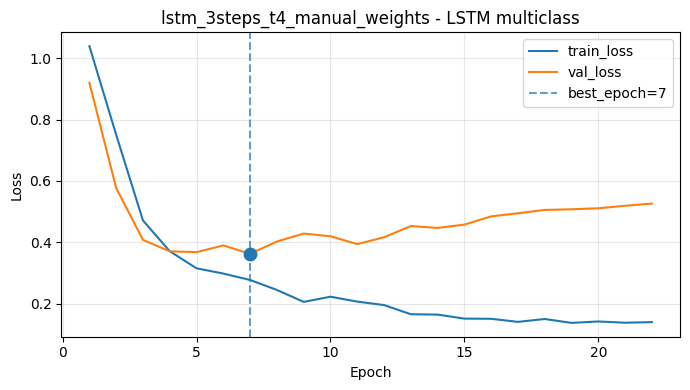


TEST FINAL
Loss     : 0.4270
Accuracy : 0.8676
F1 macro : 0.8054
Recall clase 0: 0.9590
Recall clase 1: 0.8182
Recall clase 2: 0.6818

Classification report:
              precision    recall  f1-score   support

           0     0.8797    0.9590    0.9176       122
           1     0.9070    0.8182    0.8603       143
           2     0.6000    0.6818    0.6383        22

    accuracy                         0.8676       287
   macro avg     0.7956    0.8197    0.8054       287
weighted avg     0.8719    0.8676    0.8677       287

Matriz de confusión:
[[117   5   0]
 [ 16 117  10]
 [  0   7  15]]


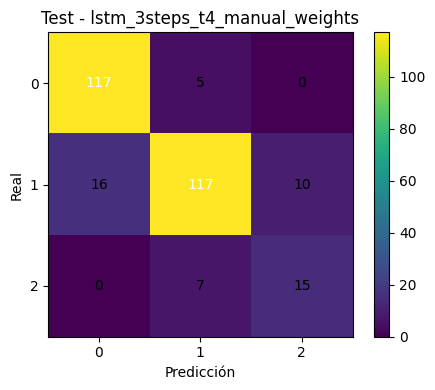


Modelo guardado en: outputs_lstm/lstm_t4_lstm_3steps_t4_manual_weights.pt


In [281]:
result = run_pipeline_lstm_t4(
    cfg=cfg,
    df=df
)

In [282]:
from sklearn.model_selection import StratifiedKFold
def run_pipeline_lstm_t4_cv(cfg, df=None):
    print("\n" + "=" * 80)
    print(f"EXPERIMENTO CV: {cfg['name']}")
    print("=" * 80)

    set_seed(cfg.get("seed", SEED))

    # -------------------------
    # Carga de datos
    # -------------------------
    if df is None:
        df_path = cfg.get("df_path", None)

        if df_path is None:
            raise ValueError(
                "Debes pasar df directamente o definir cfg['df_path']."
            )

        df = pd.read_csv(df_path)

    df = df.copy()

    id_col = cfg["id_col"]
    time_col = cfg["time_col"]
    target_col = cfg["target_col"]
    input_steps = cfg.get("input_steps", 3)

    # Opción útil si tus datos están ordenados en bloques de 4 filas
    if cfg.get("auto_create_id_time", False):
        df = df.reset_index(drop=True)
        df[id_col] = df.index // 4
        df[time_col] = (df.index % 4) + 1

    feature_cols = cfg.get("feature_cols", None)

    # -------------------------
    # Crear X e y
    # -------------------------
    X, y_raw, serie_ids, feature_cols = crear_X_y_lstm_t4(
        df=df,
        id_col=id_col,
        time_col=time_col,
        target_col=target_col,
        feature_cols=feature_cols,
        input_steps=input_steps,
    )

    print("\nShape inicial:")
    print("X:", X.shape)
    print("y:", y_raw.shape)

    assert X.ndim == 3, "X debe ser 3D: (n_series, 3, n_features)"
    assert X.shape[1] == input_steps, f"X debe tener {input_steps} puntos temporales"

    # -------------------------
    # Label encoding
    # -------------------------
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw)

    num_classes = len(label_encoder.classes_)
    n_features = X.shape[2]

    print("\nClases:")
    for i, clase in enumerate(label_encoder.classes_):
        print(f"{i} -> {clase}")

    print("\nDistribución total:")
    print(pd.Series(y).value_counts().sort_index())

    # -------------------------
    # Validación de folds
    # -------------------------
    n_splits = cfg.get("n_splits", 10)

    class_counts = pd.Series(y).value_counts().sort_index()
    min_class_count = class_counts.min()

    if min_class_count < n_splits:
        raise ValueError(
            f"No puedes usar {n_splits} folds porque la clase minoritaria "
            f"tiene solo {min_class_count} muestras. "
            f"Reduce n_splits o consigue más datos."
        )

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=cfg.get("seed", SEED)
    )

    # -------------------------
    # Contenedores globales
    # -------------------------
    fold_results = []
    histories = []

    oof_y_true = []
    oof_y_pred = []

    cm_total = np.zeros((num_classes, num_classes), dtype=int)

    out_dir = Path(cfg.get("output_dir", "outputs_lstm_cv"))
    out_dir.mkdir(parents=True, exist_ok=True)

    # =====================================================
    # LOOP DE CROSS-VALIDATION
    # =====================================================
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        print("\n" + "-" * 80)
        print(f"FOLD {fold}/{n_splits}")
        print("-" * 80)

        set_seed(cfg.get("seed", SEED) + fold)

        # -------------------------
        # Split fold
        # -------------------------
        X_train = X[train_idx]
        X_val = X[val_idx]

        y_train = y[train_idx]
        y_val = y[val_idx]

        print("Distribución train:", pd.Series(y_train).value_counts().sort_index().to_dict())
        print("Distribución val  :", pd.Series(y_val).value_counts().sort_index().to_dict())

        # -------------------------
        # Escalado sin fuga
        # -------------------------
        X_train_scaled, X_val_scaled, scaler = fit_transform_lstm_scaler(
            X_train=X_train,
            X_val=X_val,
            X_test=None
        )

        # -------------------------
        # DataLoaders
        # -------------------------
        batch_size = cfg.get("batch_size", 16)

        train_loader = make_loader(
            X_train_scaled,
            y_train,
            batch_size=batch_size,
            shuffle=True
        )

        val_loader = make_loader(
            X_val_scaled,
            y_val,
            batch_size=batch_size,
            shuffle=False
        )

        # -------------------------
        # Modelo nuevo para cada fold
        # -------------------------
        model = LSTMClassifier(
            n_features=n_features,
            num_classes=num_classes,
            hidden_size=cfg.get("hidden_size", 50),
            num_layers=cfg.get("num_layers", 3),
            dropout=cfg.get("dropout", 0.2),
        ).to(DEVICE)

        # -------------------------
        # Loss con class weights por fold
        # -------------------------
        weights = get_class_weights(
            y_train=y_train,
            num_classes=num_classes,
            cfg=cfg
        )

        criterion = nn.CrossEntropyLoss(weight=weights)

        # -------------------------
        # Optimizer Adam con weight decay
        # -------------------------
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=cfg.get("lr", 1e-3),
            weight_decay=cfg.get("weight_decay", 1e-4)
        )

        # -------------------------
        # Scheduler opcional
        # -------------------------
        scheduler = None

        if cfg.get("use_scheduler", False):
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=cfg.get("scheduler_factor", 0.5),
                patience=cfg.get("scheduler_patience", 5),
                min_lr=cfg.get("min_lr", 1e-6)
            )

        # -------------------------
        # Entrenamiento fold
        # -------------------------
        model, history_df, best_epoch, best_val_loss = train_lstm_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            num_classes=num_classes,
            epochs=cfg.get("epochs", 100),
            patience=cfg.get("patience", 15),
            min_delta=cfg.get("min_delta", 0.0),
            max_grad_norm=cfg.get("max_grad_norm", None),
            scheduler=scheduler,
            verbose=cfg.get("verbose", True)
        )

        history_df["fold"] = fold
        histories.append(history_df)

        if cfg.get("plot_each_fold", False):
            plot_loss_history(
                history_df,
                best_epoch=best_epoch,
                title=f"{cfg['name']} - Fold {fold}"
            )

        # -------------------------
        # Evaluación fold
        # -------------------------
        val_metrics = evaluate_multiclass(
            model=model,
            loader=val_loader,
            criterion=criterion,
            num_classes=num_classes
        )

        y_true = val_metrics["y_true"]
        y_pred = val_metrics["y_pred"]

        oof_y_true.extend(y_true)
        oof_y_pred.extend(y_pred)

        cm_fold = confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(num_classes))
        )

        cm_total += cm_fold

        fold_row = {
            "fold": fold,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1_macro": val_metrics["f1_macro"],
        }

        for i in range(num_classes):
            fold_row[f"val_recall_{i}"] = val_metrics[f"recall_{i}"]

        fold_results.append(fold_row)

        print("\nResultado fold:")
        print(f"Val Loss    : {val_metrics['loss']:.4f}")
        print(f"Val Accuracy: {val_metrics['acc']:.4f}")
        print(f"Val F1 macro: {val_metrics['f1_macro']:.4f}")

        for i in range(num_classes):
            print(f"Recall clase {i}: {val_metrics[f'recall_{i}']:.4f}")

        # -------------------------
        # Guardar modelo de cada fold
        # -------------------------
        if cfg.get("save_each_fold", True):
            fold_path = out_dir / f"lstm_t4_{cfg['name']}_fold_{fold}.pt"

            torch.save(
                {
                    "experiment_name": cfg["name"],
                    "fold": fold,
                    "model_state_dict": model.state_dict(),
                    "config": cfg,

                    "feature_cols": feature_cols,
                    "id_col": id_col,
                    "time_col": time_col,
                    "target_col": target_col,
                    "input_steps": input_steps,

                    "n_features": n_features,
                    "num_classes": num_classes,

                    "label_encoder_classes": label_encoder.classes_,
                    "scaler_mean": scaler.mean_,
                    "scaler_scale": scaler.scale_,

                    "best_epoch": best_epoch,
                    "best_val_loss": best_val_loss,

                    "val_metrics": {
                        "loss": val_metrics["loss"],
                        "acc": val_metrics["acc"],
                        "f1_macro": val_metrics["f1_macro"],
                        **{
                            f"recall_{i}": val_metrics[f"recall_{i}"]
                            for i in range(num_classes)
                        }
                    },
                    "history": history_df,
                },
                fold_path
            )

    # =====================================================
    # RESULTADOS GLOBALES CV
    # =====================================================
    results_df = pd.DataFrame(fold_results)
    history_all_df = pd.concat(histories, ignore_index=True)

    oof_y_true = np.array(oof_y_true)
    oof_y_pred = np.array(oof_y_pred)

    print("\n" + "=" * 80)
    print("RESULTADOS CROSS-VALIDATION")
    print("=" * 80)

    print("\nResultados por fold:")
    print(results_df)

    metric_cols = [
        c for c in results_df.columns
        if c not in ["fold"]
    ]

    summary_rows = []

    for col in metric_cols:
        summary_rows.append({
            "metric": col,
            "mean": results_df[col].mean(),
            "std": results_df[col].std(),
            "min": results_df[col].min(),
            "max": results_df[col].max(),
        })

    summary_df = pd.DataFrame(summary_rows)

    print("\nResumen CV:")
    print(summary_df)

    print("\nClassification report OOF:")
    print(
        classification_report(
            oof_y_true,
            oof_y_pred,
            target_names=[str(c) for c in label_encoder.classes_],
            digits=4,
            zero_division=0
        )
    )

    print("\nMatriz de confusión agregada:")
    print(cm_total)

    plot_confusion_matrix(
        cm_total,
        class_names=[str(c) for c in label_encoder.classes_],
        title=f"CV agregada - {cfg['name']}"
    )

    # -------------------------
    # Guardar resumen global
    # -------------------------
    results_path = out_dir / f"cv_results_{cfg['name']}.csv"
    summary_path = out_dir / f"cv_summary_{cfg['name']}.csv"
    history_path = out_dir / f"cv_history_{cfg['name']}.csv"

    results_df.to_csv(results_path, index=False)
    summary_df.to_csv(summary_path, index=False)
    history_all_df.to_csv(history_path, index=False)

    torch.save(
        {
            "experiment_name": cfg["name"],
            "config": cfg,

            "feature_cols": feature_cols,
            "id_col": id_col,
            "time_col": time_col,
            "target_col": target_col,
            "input_steps": input_steps,

            "n_features": n_features,
            "num_classes": num_classes,
            "label_encoder_classes": label_encoder.classes_,

            "fold_results": results_df,
            "summary": summary_df,
            "history": history_all_df,

            "oof_y_true": oof_y_true,
            "oof_y_pred": oof_y_pred,
            "confusion_matrix_total": cm_total,
        },
        out_dir / f"cv_package_{cfg['name']}.pt"
    )

    print(f"\nResultados guardados en: {out_dir}")

    return {
        "experiment": cfg["name"],
        "results_df": results_df,
        "summary_df": summary_df,
        "history_df": history_all_df,
        "oof_y_true": oof_y_true,
        "oof_y_pred": oof_y_pred,
        "confusion_matrix": cm_total,
        "label_encoder": label_encoder,
        "feature_cols": feature_cols,
        "output_dir": out_dir,
    }

In [285]:
cfg = {
    "name": "lstm_3steps_t4_cv10",

    "id_col": "PATNO",
    "time_col": "EVENT_ID",
    "target_col": "STAGE",

    "feature_cols": df.filter(regex=r'NP[123]').columns.to_list()+['NHY'],

    "input_steps": 3,

    # Cross-validation
    "n_splits": 10,

    # Arquitectura LSTM
    "hidden_size": 30,
    "num_layers": 2,
    "dropout": 0.2,

    # Entrenamiento
    "batch_size": 16,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 100,

    # Early stopping
    "patience": 15,
    "min_delta": 0.0005,

    # Class weights
    # Opción 1: manual
    "class_weights": [1.0, 2.5, 1.1],

    # Opción 2: automático
    # "class_weights": "auto",

    # Scheduler opcional
    "use_scheduler": True,
    "scheduler_factor": 0.5,
    "scheduler_patience": 5,
    "min_lr": 1e-6,

    # Gradient clipping opcional
    "max_grad_norm": 1.0,

    # Guardado y plots
    "save_each_fold": False,
    "plot_each_fold": True,
    "output_dir": "outputs_lstm_cv",

    "seed": 42,
    "verbose": True,
}


EXPERIMENTO CV: lstm_3steps_t4_cv10

Shape inicial:
X: (956, 3, 60)
y: (956,)

Clases:
0 -> 0
1 -> 1
2 -> 2

Distribución total:
0    408
1    476
2     72
Name: count, dtype: int64

--------------------------------------------------------------------------------
FOLD 1/10
--------------------------------------------------------------------------------
Distribución train: {0: 367, 1: 428, 2: 65}
Distribución val  : {0: 41, 1: 48, 2: 7}

Class weights:
Clase 0: 1.0000
Clase 1: 2.5000
Clase 2: 1.1000
[001] train_loss=0.9275 | val_loss=0.6163 | val_acc=0.8854 | val_f1_macro=0.6145 | recall_0=0.9756 | recall_1=0.9375 | recall_2=0.0000 <-- mejor val_loss
[002] train_loss=0.4479 | val_loss=0.3264 | val_acc=0.8750 | val_f1_macro=0.6067 | recall_0=1.0000 | recall_1=0.8958 | recall_2=0.0000 <-- mejor val_loss
[003] train_loss=0.3284 | val_loss=0.2935 | val_acc=0.8646 | val_f1_macro=0.6002 | recall_0=0.9268 | recall_1=0.9375 | recall_2=0.0000 <-- mejor val_loss
[004] train_loss=0.2979 | val_los

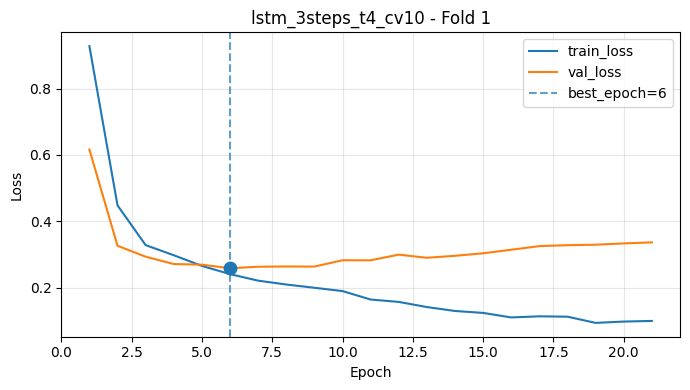


Resultado fold:
Val Loss    : 0.2586
Val Accuracy: 0.8958
Val F1 macro: 0.7498
Recall clase 0: 1.0000
Recall clase 1: 0.8958
Recall clase 2: 0.2857

--------------------------------------------------------------------------------
FOLD 2/10
--------------------------------------------------------------------------------
Distribución train: {0: 367, 1: 428, 2: 65}
Distribución val  : {0: 41, 1: 48, 2: 7}

Class weights:
Clase 0: 1.0000
Clase 1: 2.5000
Clase 2: 1.1000
[001] train_loss=0.9085 | val_loss=0.6203 | val_acc=0.8646 | val_f1_macro=0.5996 | recall_0=0.9756 | recall_1=0.8958 | recall_2=0.0000 <-- mejor val_loss
[002] train_loss=0.4567 | val_loss=0.3188 | val_acc=0.8750 | val_f1_macro=0.6071 | recall_0=0.9756 | recall_1=0.9167 | recall_2=0.0000 <-- mejor val_loss
[003] train_loss=0.3278 | val_loss=0.2695 | val_acc=0.8854 | val_f1_macro=0.6145 | recall_0=0.9756 | recall_1=0.9375 | recall_2=0.0000 <-- mejor val_loss
[004] train_loss=0.2937 | val_loss=0.2410 | val_acc=0.8750 | val_f1

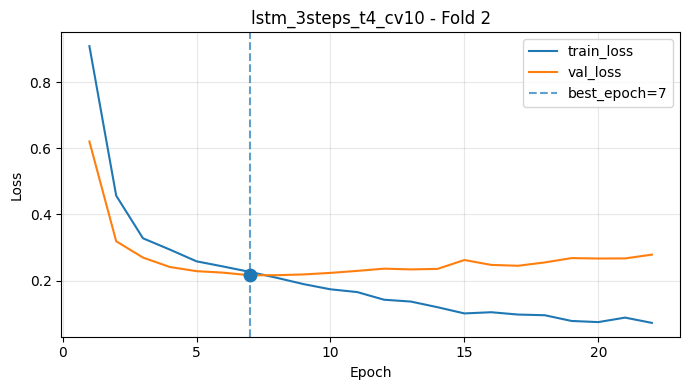


Resultado fold:
Val Loss    : 0.2158
Val Accuracy: 0.9167
Val F1 macro: 0.8618
Recall clase 0: 0.9512
Recall clase 1: 0.9375
Recall clase 2: 0.5714

--------------------------------------------------------------------------------
FOLD 3/10
--------------------------------------------------------------------------------
Distribución train: {0: 367, 1: 428, 2: 65}
Distribución val  : {0: 41, 1: 48, 2: 7}

Class weights:
Clase 0: 1.0000
Clase 1: 2.5000
Clase 2: 1.1000
[001] train_loss=0.9157 | val_loss=0.6328 | val_acc=0.8438 | val_f1_macro=0.5856 | recall_0=0.9024 | recall_1=0.9167 | recall_2=0.0000 <-- mejor val_loss
[002] train_loss=0.4475 | val_loss=0.4082 | val_acc=0.8125 | val_f1_macro=0.5636 | recall_0=0.8293 | recall_1=0.9167 | recall_2=0.0000 <-- mejor val_loss
[003] train_loss=0.3328 | val_loss=0.3639 | val_acc=0.8125 | val_f1_macro=0.5637 | recall_0=0.8537 | recall_1=0.8958 | recall_2=0.0000 <-- mejor val_loss
[004] train_loss=0.2875 | val_loss=0.3533 | val_acc=0.8333 | val_f1

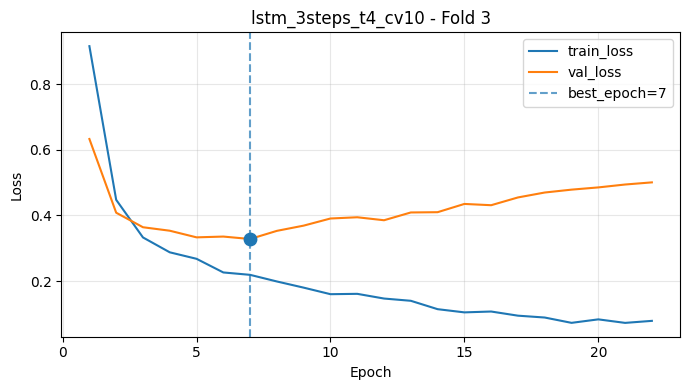


Resultado fold:
Val Loss    : 0.3281
Val Accuracy: 0.8646
Val F1 macro: 0.7867
Recall clase 0: 0.8780
Recall clase 1: 0.9167
Recall clase 2: 0.4286

--------------------------------------------------------------------------------
FOLD 4/10
--------------------------------------------------------------------------------
Distribución train: {0: 367, 1: 428, 2: 65}
Distribución val  : {0: 41, 1: 48, 2: 7}

Class weights:
Clase 0: 1.0000
Clase 1: 2.5000
Clase 2: 1.1000
[001] train_loss=0.8699 | val_loss=0.5911 | val_acc=0.8542 | val_f1_macro=0.5922 | recall_0=0.9756 | recall_1=0.8750 | recall_2=0.0000 <-- mejor val_loss
[002] train_loss=0.4565 | val_loss=0.3216 | val_acc=0.8542 | val_f1_macro=0.5930 | recall_0=0.9024 | recall_1=0.9375 | recall_2=0.0000 <-- mejor val_loss
[003] train_loss=0.3273 | val_loss=0.2708 | val_acc=0.8542 | val_f1_macro=0.5931 | recall_0=0.8780 | recall_1=0.9583 | recall_2=0.0000 <-- mejor val_loss
[004] train_loss=0.2845 | val_loss=0.2695 | val_acc=0.8542 | val_f1

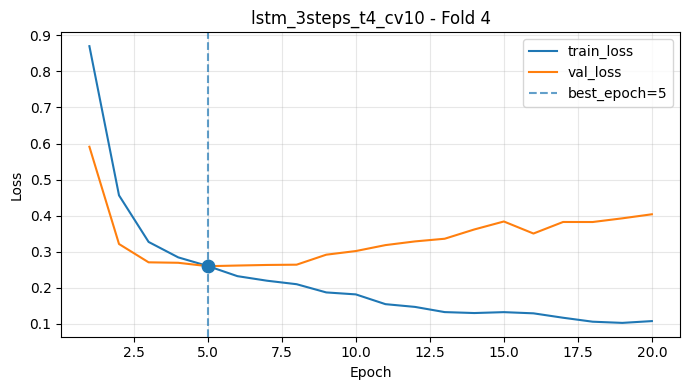


Resultado fold:
Val Loss    : 0.2601
Val Accuracy: 0.9062
Val F1 macro: 0.8379
Recall clase 0: 0.9512
Recall clase 1: 0.9167
Recall clase 2: 0.5714

--------------------------------------------------------------------------------
FOLD 5/10
--------------------------------------------------------------------------------
Distribución train: {0: 367, 1: 428, 2: 65}
Distribución val  : {0: 41, 1: 48, 2: 7}

Class weights:
Clase 0: 1.0000
Clase 1: 2.5000
Clase 2: 1.1000
[001] train_loss=0.9301 | val_loss=0.6699 | val_acc=0.8333 | val_f1_macro=0.5782 | recall_0=0.9024 | recall_1=0.8958 | recall_2=0.0000 <-- mejor val_loss
[002] train_loss=0.4711 | val_loss=0.3429 | val_acc=0.8646 | val_f1_macro=0.6000 | recall_0=0.9512 | recall_1=0.9167 | recall_2=0.0000 <-- mejor val_loss
[003] train_loss=0.3339 | val_loss=0.3048 | val_acc=0.8542 | val_f1_macro=0.5928 | recall_0=0.9268 | recall_1=0.9167 | recall_2=0.0000 <-- mejor val_loss
[004] train_loss=0.2722 | val_loss=0.3094 | val_acc=0.8229 | val_f1

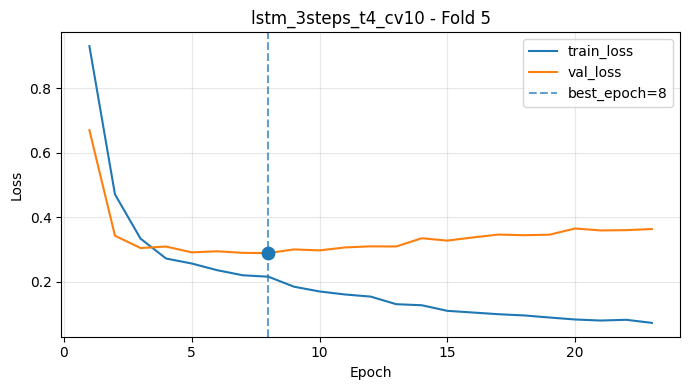


Resultado fold:
Val Loss    : 0.2890
Val Accuracy: 0.8750
Val F1 macro: 0.7796
Recall clase 0: 0.9268
Recall clase 1: 0.8958
Recall clase 2: 0.4286

--------------------------------------------------------------------------------
FOLD 6/10
--------------------------------------------------------------------------------
Distribución train: {0: 367, 1: 428, 2: 65}
Distribución val  : {0: 41, 1: 48, 2: 7}

Class weights:
Clase 0: 1.0000
Clase 1: 2.5000
Clase 2: 1.1000
[001] train_loss=0.9890 | val_loss=0.6934 | val_acc=0.8438 | val_f1_macro=0.5852 | recall_0=0.9512 | recall_1=0.8750 | recall_2=0.0000 <-- mejor val_loss
[002] train_loss=0.4716 | val_loss=0.4010 | val_acc=0.8438 | val_f1_macro=0.5852 | recall_0=0.9512 | recall_1=0.8750 | recall_2=0.0000 <-- mejor val_loss
[003] train_loss=0.3290 | val_loss=0.3895 | val_acc=0.8333 | val_f1_macro=0.5778 | recall_0=0.9512 | recall_1=0.8542 | recall_2=0.0000 <-- mejor val_loss
[004] train_loss=0.2856 | val_loss=0.3852 | val_acc=0.8646 | val_f1

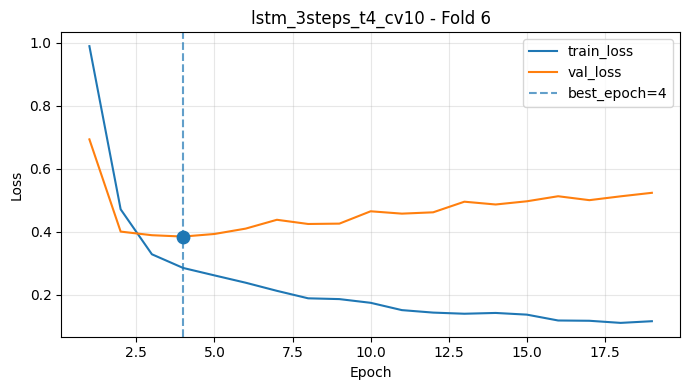


Resultado fold:
Val Loss    : 0.3852
Val Accuracy: 0.8646
Val F1 macro: 0.7391
Recall clase 0: 0.9512
Recall clase 1: 0.8750
Recall clase 2: 0.2857

--------------------------------------------------------------------------------
FOLD 7/10
--------------------------------------------------------------------------------
Distribución train: {0: 368, 1: 429, 2: 64}
Distribución val  : {0: 40, 1: 47, 2: 8}

Class weights:
Clase 0: 1.0000
Clase 1: 2.5000
Clase 2: 1.1000
[001] train_loss=0.9209 | val_loss=0.7010 | val_acc=0.8316 | val_f1_macro=0.5808 | recall_0=0.9250 | recall_1=0.8936 | recall_2=0.0000 <-- mejor val_loss
[002] train_loss=0.4591 | val_loss=0.4267 | val_acc=0.8421 | val_f1_macro=0.5880 | recall_0=0.9500 | recall_1=0.8936 | recall_2=0.0000 <-- mejor val_loss
[003] train_loss=0.3121 | val_loss=0.3905 | val_acc=0.8316 | val_f1_macro=0.5808 | recall_0=0.9250 | recall_1=0.8936 | recall_2=0.0000 <-- mejor val_loss
[004] train_loss=0.2769 | val_loss=0.3751 | val_acc=0.8421 | val_f1

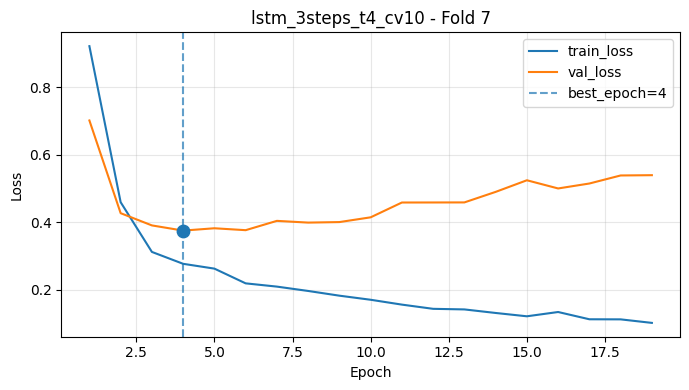


Resultado fold:
Val Loss    : 0.3751
Val Accuracy: 0.8421
Val F1 macro: 0.6577
Recall clase 0: 0.9250
Recall clase 1: 0.8936
Recall clase 2: 0.1250

--------------------------------------------------------------------------------
FOLD 8/10
--------------------------------------------------------------------------------
Distribución train: {0: 368, 1: 429, 2: 64}
Distribución val  : {0: 40, 1: 47, 2: 8}

Class weights:
Clase 0: 1.0000
Clase 1: 2.5000
Clase 2: 1.1000
[001] train_loss=0.9836 | val_loss=0.6603 | val_acc=0.8632 | val_f1_macro=0.6032 | recall_0=0.9500 | recall_1=0.9362 | recall_2=0.0000 <-- mejor val_loss
[002] train_loss=0.4784 | val_loss=0.3297 | val_acc=0.8632 | val_f1_macro=0.6035 | recall_0=0.9250 | recall_1=0.9574 | recall_2=0.0000 <-- mejor val_loss
[003] train_loss=0.3441 | val_loss=0.2960 | val_acc=0.8421 | val_f1_macro=0.5887 | recall_0=0.8750 | recall_1=0.9574 | recall_2=0.0000 <-- mejor val_loss
[004] train_loss=0.2947 | val_loss=0.2757 | val_acc=0.8632 | val_f1

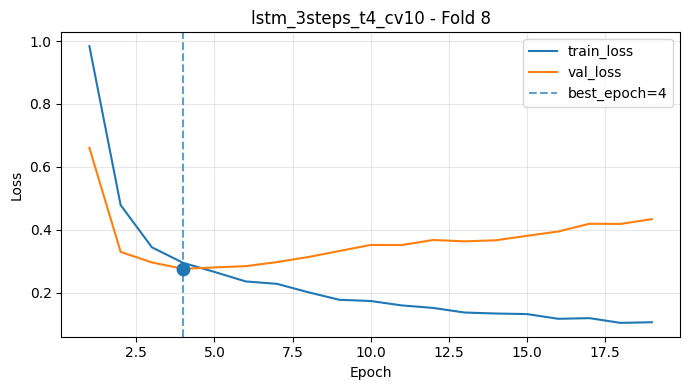


Resultado fold:
Val Loss    : 0.2757
Val Accuracy: 0.8632
Val F1 macro: 0.6730
Recall clase 0: 0.9000
Recall clase 1: 0.9574
Recall clase 2: 0.1250

--------------------------------------------------------------------------------
FOLD 9/10
--------------------------------------------------------------------------------
Distribución train: {0: 367, 1: 429, 2: 65}
Distribución val  : {0: 41, 1: 47, 2: 7}

Class weights:
Clase 0: 1.0000
Clase 1: 2.5000
Clase 2: 1.1000
[001] train_loss=0.9030 | val_loss=0.5717 | val_acc=0.8421 | val_f1_macro=0.5844 | recall_0=0.9268 | recall_1=0.8936 | recall_2=0.0000 <-- mejor val_loss
[002] train_loss=0.4275 | val_loss=0.3654 | val_acc=0.8316 | val_f1_macro=0.5770 | recall_0=0.9268 | recall_1=0.8723 | recall_2=0.0000 <-- mejor val_loss
[003] train_loss=0.3256 | val_loss=0.3473 | val_acc=0.8211 | val_f1_macro=0.5699 | recall_0=0.8780 | recall_1=0.8936 | recall_2=0.0000 <-- mejor val_loss
[004] train_loss=0.2755 | val_loss=0.3477 | val_acc=0.8421 | val_f1

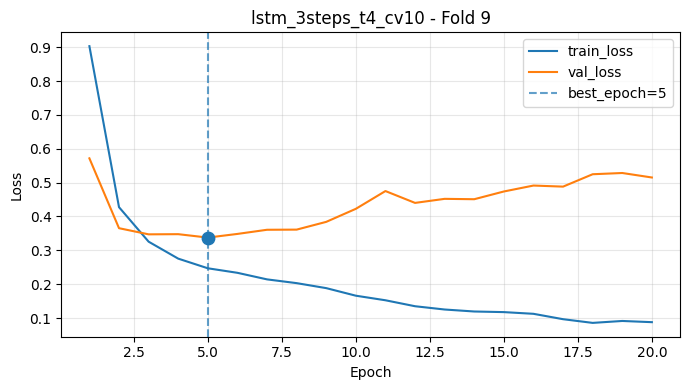


Resultado fold:
Val Loss    : 0.3377
Val Accuracy: 0.8632
Val F1 macro: 0.7932
Recall clase 0: 0.9512
Recall clase 1: 0.8298
Recall clase 2: 0.5714

--------------------------------------------------------------------------------
FOLD 10/10
--------------------------------------------------------------------------------
Distribución train: {0: 367, 1: 429, 2: 65}
Distribución val  : {0: 41, 1: 47, 2: 7}

Class weights:
Clase 0: 1.0000
Clase 1: 2.5000
Clase 2: 1.1000
[001] train_loss=0.9865 | val_loss=0.6595 | val_acc=0.8421 | val_f1_macro=0.5837 | recall_0=0.9756 | recall_1=0.8511 | recall_2=0.0000 <-- mejor val_loss
[002] train_loss=0.4570 | val_loss=0.3637 | val_acc=0.8526 | val_f1_macro=0.5921 | recall_0=0.9024 | recall_1=0.9362 | recall_2=0.0000 <-- mejor val_loss
[003] train_loss=0.3244 | val_loss=0.3118 | val_acc=0.8632 | val_f1_macro=0.5994 | recall_0=0.9268 | recall_1=0.9362 | recall_2=0.0000 <-- mejor val_loss
[004] train_loss=0.2821 | val_loss=0.2898 | val_acc=0.8737 | val_f

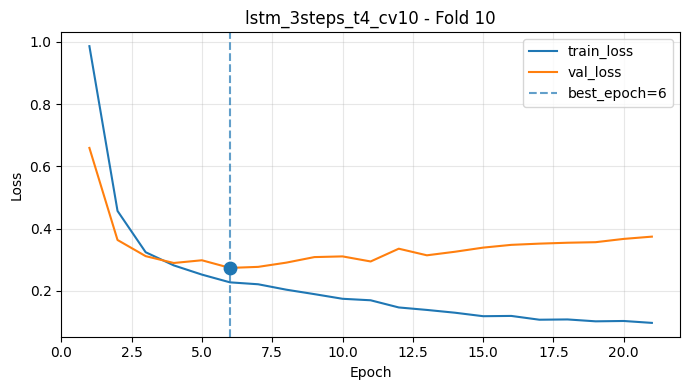


Resultado fold:
Val Loss    : 0.2740
Val Accuracy: 0.9053
Val F1 macro: 0.8157
Recall clase 0: 0.9512
Recall clase 1: 0.9362
Recall clase 2: 0.4286

RESULTADOS CROSS-VALIDATION

Resultados por fold:
   fold  best_epoch  best_val_loss  val_loss   val_acc  val_f1_macro  \
0     1           6       0.258650  0.258650  0.895833      0.749774   
1     2           7       0.215786  0.215786  0.916667      0.861800   
2     3           7       0.328088  0.328088  0.864583      0.786725   
3     4           5       0.260074  0.260074  0.906250      0.837881   
4     5           8       0.289036  0.289036  0.875000      0.779556   
5     6           4       0.385161  0.385161  0.864583      0.739134   
6     7           4       0.375148  0.375148  0.842105      0.657715   
7     8           4       0.275692  0.275692  0.863158      0.673029   
8     9           5       0.337680  0.337680  0.863158      0.793168   
9    10           6       0.273982  0.273982  0.905263      0.815659   

   val_

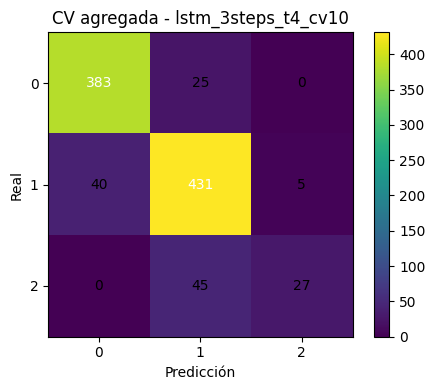


Resultados guardados en: outputs_lstm_cv


In [286]:
result_cv = run_pipeline_lstm_t4_cv(
    cfg=cfg,
    df=df
)